**Bird Species Observation Analysis** 

##### **Project Type**    - EDA

**Project Summary**

This project investigates the distribution and diversity of bird species across two key ecosystems: forests and grasslands. Using a comprehensive bird observation dataset, the study applies rigorous data cleaning, exploratory data analysis, and SQL-based transformations to uncover patterns in species richness, habitat preference, and temporal activity.

By developing interactive dashboards, the analysis visualizes critical metrics such as total bird counts, species distribution by habitat and season, environmental influences on bird activity, and observer trends. Key findings reveal equal biodiversity contribution from forests and grasslands, the significant role of moderate temperature and humidity in bird behavior, and seasonal peaks aligning with migration patterns.

These insights enable targeted conservation efforts, habitat management strategies, and support for eco-tourism and policy development. The project demonstrates the power of data-driven approaches in ecological research and offers actionable recommendations to enhance biodiversity monitoring and protection.

**Problem Statement**

Understanding bird species distribution across different ecosystems is essential for effective biodiversity conservation and environmental management. However, bird observation data is often complex, containing variations in habitat types, environmental conditions, and temporal factors such as seasons and time of day.

The challenge is to analyze this multi-dimensional dataset to:

Identify patterns in bird species distribution across forest and grassland habitats
Understand how environmental factors (temperature, humidity, weather) influence bird activity
Detect seasonal and temporal trends in bird observations
Evaluate species diversity and abundance across locations

Without structured analysis, it is difficult to derive meaningful insights that can support conservation strategies, habitat management, and ecological decision-making.

**Objectives of Exploratory Data Analysis (EDA)**

The main objective of EDA in this project is to clean, understand, and explore the dataset to uncover meaningful patterns and prepare it for advanced analysis.

1. Data Understanding
Examine dataset structure, features, and data types
Identify key variables related to species, habitat, time, and environment
2. Data Cleaning
Detect and handle missing values
Identify and remove duplicate records
Validate and treat outliers in environmental variables
3. Data Transformation
Convert date and time into standard formats
Create derived features such as:
Season
Time of day
Temperature categories
4. Univariate Analysis
Analyze distribution of:
Bird counts
Temperature, humidity
Observation frequency
5. Bivariate & Multivariate Analysis
Study relationships between:
Habitat type and species distribution
Environmental factors and bird activity
Time (month/season) and observations
6. Pattern Identification
Identify seasonal trends in bird activity
Detect habitat preferences of species
Highlight biodiversity hotspots
7. Data Preparation for Visualization & SQL
Structure data for dashboards and reporting
Ensure consistency for SQL queries and analysis

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### 1. Dataset Loading : Bird_Monitoring_Data_FOREST

In [2]:
import pandas as pd
# Specify the file path
file_path = r"C:\Users\hp\OneDrive\Music\Documents\Bird_Monitoring_Data_FOREST.XLSX"

# Read the Excel file with multiple sheets
excel_data = pd.ExcelFile(file_path)

# Get all sheet names
sheet_names = excel_data.sheet_names

# Read data from all sheets into a dictionary
sheets_dict = {sheet: excel_data.parse(sheet) for sheet in sheet_names}

In [3]:
#  Convert sheets_dict to a single DataFrame; this will add a new sheet column at the last.
combined_df = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict.items()],
    ignore_index=True
)

In [4]:
#  Drop the 'Sheet' column
forest_df= combined_df.drop(columns=['Sheet'])

### Dataset First View

In [5]:
forest_df.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,83803,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,90935,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,84865,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,93634,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,88394,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [6]:
forest_df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt'],
      dtype='object')

| Column Name                     | Description                                                   |
| ------------------------------- | ------------------------------------------------------------- |
| **Admin_Unit_Code**             | Code representing the administrative unit (e.g., park/region) |
| **Sub_Unit_Code**               | Sub-division within the admin unit                            |
| **Site_Name**                   | Name of the monitoring site                                   |
| **Plot_Name**                   | Specific plot within the site                                 |
| **Location_Type**               | Type of habitat/location (forest, grassland, etc.)            |
| **Year**                        | Year of observation                                           |
| **Date**                        | Date of bird observation                                      |
| **Start_Time**                  | Survey start time                                             |
| **End_Time**                    | Survey end time                                               |
| **Observer**                    | Person who recorded the observation                           |
| **Visit**                       | Visit number (repeat surveys)                                 |
| **Interval_Length**             | Duration of observation interval                              |
| **ID_Method**                   | Method used to identify birds (visual/audio)                  |
| **Distance**                    | Distance of bird from observer                                |
| **Flyover_Observed**            | Whether bird was flying overhead                              |
| **Sex**                         | Gender of the bird                                            |
| **Common_Name**                 | Bird’s common name                                            |
| **Scientific_Name**             | Bird’s scientific name                                        |
| **AcceptedTSN**                 | Taxonomic Serial Number                                       |
| **NPSTaxonCode**                | National Park Service taxon code                              |
| **AOU_Code**                    | American Ornithological Union code                            |
| **PIF_Watchlist_Status**        | Conservation concern indicator                                |
| **Regional_Stewardship_Status** | Regional conservation importance                              |
| **Temperature**                 | Temperature during observation                                |
| **Humidity**                    | Humidity level                                                |
| **Sky**                         | Sky condition (clear, cloudy, etc.)                           |
| **Wind**                        | Wind condition                                                |
| **Disturbance**                 | Environmental disturbance level                               |
| **Initial_Three_Min_Cnt**       | Number of birds counted in first 3 minutes                    |


In [7]:
# Dataset Rows & Columns count
forest_df.shape

(8546, 29)

In [8]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8546 non-null   object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    8546 non-null   object        
 4   Location_Type                8546 non-null   object        
 5   Year                         8546 non-null   int64         
 6   Date                         8546 non-null   datetime64[ns]
 7   Start_Time                   8546 non-null   object        
 8   End_Time                     8546 non-null   object        
 9   Observer                     8546 non-null   object        
 10  Visit                        8546 non-null   int64         
 11  Interval_Length              8546 non-null 

In [9]:
# Checking Miss Value
forest_df.isnull().sum().sort_values(ascending=False)

Sub_Unit_Code                  7824
Sex                            5183
Distance                         92
AcceptedTSN                       9
ID_Method                         1
Admin_Unit_Code                   0
Scientific_Name                   0
Disturbance                       0
Wind                              0
Sky                               0
Humidity                          0
Temperature                       0
Regional_Stewardship_Status       0
PIF_Watchlist_Status              0
AOU_Code                          0
NPSTaxonCode                      0
Flyover_Observed                  0
Common_Name                       0
Interval_Length                   0
Visit                             0
Observer                          0
End_Time                          0
Start_Time                        0
Date                              0
Year                              0
Location_Type                     0
Plot_Name                         0
Site_Name                   

## Checking Duplicates

In [10]:
# Count total duplicates
forest_df.duplicated().sum()

0

In [11]:
forest_df.duplicated(subset=['Common_Name','Plot_Name','Date','Start_Time']).sum()

1541

In [12]:
print("Before:", len(forest_df))
forest_df = forest_df.drop_duplicates(subset=['Common_Name','Plot_Name','Date','Start_Time'])
print("After:", len(forest_df))

Before: 8546
After: 7005


In [13]:
forest_df= forest_df.drop(columns=['Sub_Unit_Code'])
# Reason: ~91% missing → unreliable

In [14]:
forest_df['Sex'] = forest_df['Sex'].fillna('Unknown')

In [15]:
forest_df['ID_Method'] = forest_df['ID_Method'].fillna(forest_df['ID_Method'].mode()[0])

In [16]:
forest_df['Distance'] = forest_df['Distance'].astype(str)

# extract numbers only
forest_df['Distance'] = forest_df['Distance'].str.extract('(\d+)')

forest_df['Distance'] = pd.to_numeric(forest_df['Distance'], errors='coerce')

# fill missing
forest_df['Distance'] = forest_df['Distance'].fillna(forest_df['Distance'].median())

In [17]:
forest_df['AcceptedTSN'] = forest_df['AcceptedTSN'].fillna(0)

In [18]:
forest_df['Date'] = pd.to_datetime(forest_df['Date'], errors='coerce')

In [19]:
forest_df['Initial_Three_Min_Cnt'] = forest_df['Initial_Three_Min_Cnt'].astype(int)

### Handling Text Data

In [20]:
forest_df['Common_Name'] = forest_df['Common_Name'].str.strip().str.title()
forest_df['Scientific_Name'] = forest_df['Scientific_Name'].str.strip().str.title()
forest_df['Observer'] = forest_df['Observer'].str.strip()

In [21]:
forest_df.describe()

,Year,Date,Visit,Distance,AcceptedTSN,NPSTaxonCode,Temperature,Humidity,Initial_Three_Min_Cnt
count,7005.0,7005,7005.000000,7005.0,7005.000000,7005.000000,7005.000000,7005.000000,7005.000000
mean,2018.0,2018-06-12 19:57:25.824411136,1.483655,50.0,248327.404996,139536.649393,21.874061,77.939129,0.544468
min,2018.0,2018-05-07 00:00:00,1.000000,50.0,0.000000,76625.000000,11.000000,17.500000,0.000000
25%,2018.0,2018-05-29 00:00:00,1.000000,50.0,178359.000000,85846.000000,19.299999,72.599998,0.000000
50%,2018.0,2018-06-12 00:00:00,1.000000,50.0,179021.000000,88350.000000,21.799999,79.199997,1.000000
75%,2018.0,2018-07-02 00:00:00,2.000000,50.0,179759.000000,94215.000000,24.400000,84.500000,1.000000
max,2018.0,2018-07-15 00:00:00,2.000000,50.0,950106.000000,926917.000000,34.400002,97.900002,1.000000
std,0.0,NaN,0.499768,0.0,187071.635645,161795.799545,3.683786,9.313202,0.498054


In [22]:
forest_df.shape

(7005, 28)

### Detecting outliers

In [23]:
# select numeric columns
numeric_cols = forest_df.select_dtypes(include=['int64', 'float64'])

outliers = {}

for col in numeric_cols.columns:
    Q1 = forest_df[col].quantile(0.25)
    Q3 = forest_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = forest_df[(forest_df[col] < lower) | (forest_df[col] > upper)]


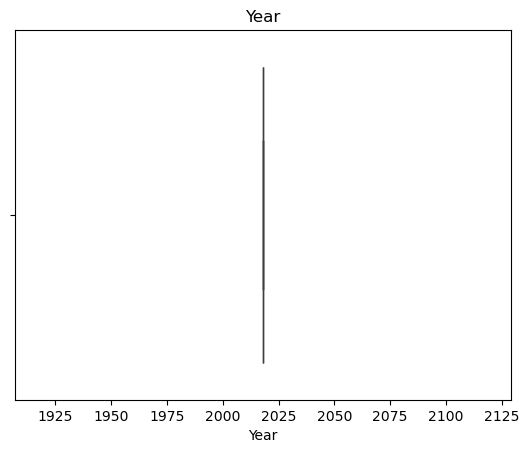

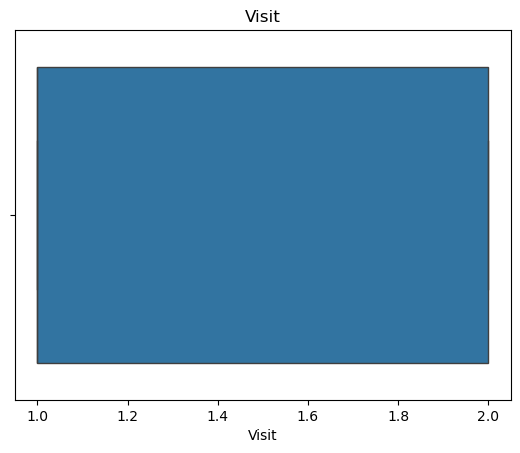

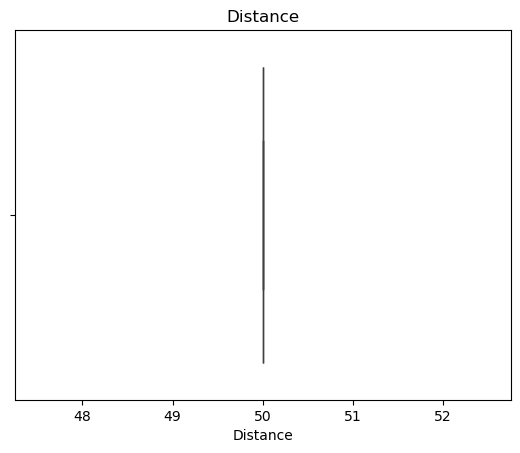

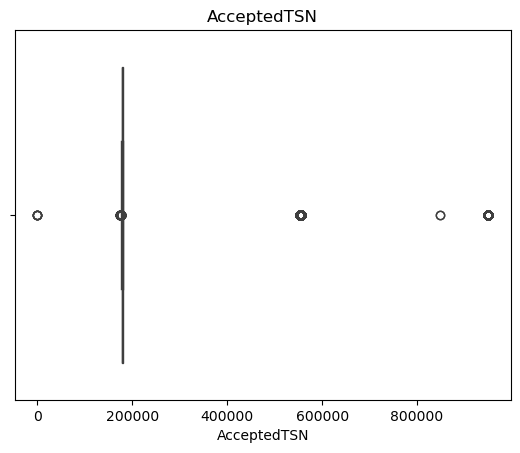

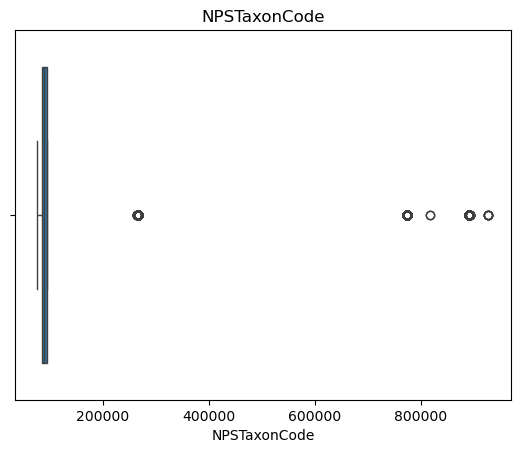

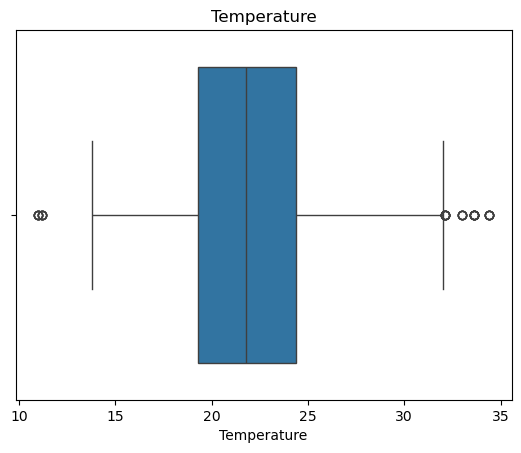

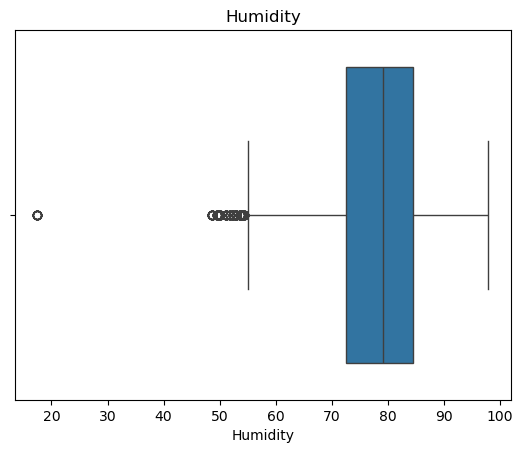

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols.columns:
    sns.boxplot(x=forest_df[col])
    plt.title(col)
    plt.show()

In [25]:
numeric_cols.describe()

,Year,Visit,Distance,AcceptedTSN,NPSTaxonCode,Temperature,Humidity
count,7005.0,7005.000000,7005.0,7005.000000,7005.000000,7005.000000,7005.000000
mean,2018.0,1.483655,50.0,248327.404996,139536.649393,21.874061,77.939129
std,0.0,0.499768,0.0,187071.635645,161795.799545,3.683786,9.313202
min,2018.0,1.000000,50.0,0.000000,76625.000000,11.000000,17.500000
25%,2018.0,1.000000,50.0,178359.000000,85846.000000,19.299999,72.599998
50%,2018.0,1.000000,50.0,179021.000000,88350.000000,21.799999,79.199997
75%,2018.0,2.000000,50.0,179759.000000,94215.000000,24.400000,84.500000
max,2018.0,2.000000,50.0,950106.000000,926917.000000,34.400002,97.900002


In [26]:
forest_df['Humidity'] = forest_df['Humidity'].clip(lower=50)

### 2. Dataset Loading : Bird_Monitoring_Data_GrassLand

In [27]:
# Specify the file path
file_path = r"C:\Users\hp\OneDrive\Music\Documents\Bird_Monitoring_Data_GRASSLAND.XLSX"

# Read the Excel file with multiple sheets
excel_data1 = pd.ExcelFile(file_path)

# Get all sheet names
sheet_names1 = excel_data.sheet_names

# Read data from all sheets into a dictionary
sheets_dict1 = {sheet: excel_data.parse(sheet) for sheet in sheet_names1}

In [28]:
#  Convert sheets_dict to a single DataFrame; this will add a new sheet column at the last.
combined_df1 = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict1.items()],
    ignore_index=True
)

In [29]:
#  Drop the 'Sheet' column
grassland_df = combined_df1.drop(columns=['Sheet'])

In [30]:
grassland_df.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,83803,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,90935,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,84865,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,93634,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,88394,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [31]:
grassland_df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt'],
      dtype='object')

In [32]:
grassland_df.shape

(8546, 29)

In [33]:
grassland_df.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  7824
Site_Name                         0
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                         92
Flyover_Observed                  0
Sex                            5183
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                       9
NPSTaxonCode                      0
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                 

In [34]:
grassland_df['Sex'] = grassland_df['Sex'].fillna('Unknown')

### Checking And Handling Duplicates

In [35]:
grassland_df.duplicated(subset=['Common_Name','Plot_Name','Date','Start_Time']).sum()

1541

In [36]:
print("Before:", len(grassland_df))
grassland_df = grassland_df.drop_duplicates(subset=['Common_Name','Plot_Name','Date','Start_Time'])
print("After:", len(grassland_df))

Before: 8546
After: 7005


In [37]:
grassland_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7005 entries, 0 to 8544
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              7005 non-null   object        
 1   Sub_Unit_Code                582 non-null    object        
 2   Site_Name                    7005 non-null   object        
 3   Plot_Name                    7005 non-null   object        
 4   Location_Type                7005 non-null   object        
 5   Year                         7005 non-null   int64         
 6   Date                         7005 non-null   datetime64[ns]
 7   Start_Time                   7005 non-null   object        
 8   End_Time                     7005 non-null   object        
 9   Observer                     7005 non-null   object        
 10  Visit                        7005 non-null   int64         
 11  Interval_Length              7005 non-null   obj

In [38]:
grassland_df['Common_Name'] = grassland_df['Common_Name'].str.strip().str.title()
grassland_df['Scientific_Name'] = grassland_df['Scientific_Name'].str.strip().str.title()

In [39]:
grassland_df['Date'] = pd.to_datetime(grassland_df['Date'], errors='coerce')

In [40]:
grassland_df['Start_Time'] = pd.to_datetime(grassland_df['Start_Time'], format='%H:%M:%S', errors='coerce')
grassland_df['End_Time'] = pd.to_datetime(grassland_df['End_Time'], format='%H:%M:%S', errors='coerce')

### 5. Handle outliers


In [41]:

# Humidity: cap at realistic bounds
grassland_df['Humidity'] = grassland_df['Humidity'].clip(lower=50, upper=95)

# Temperature: cap at realistic bounds
grassland_df['Temperature'] = grassland_df['Temperature'].clip(lower=12, upper=35)

# Count_per_Min: log-transform to reduce skew
grassland_df['Log_Count'] = np.log1p(grassland_df['Initial_Three_Min_Cnt'])



In [42]:
forest_df.columns

Index(['Admin_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Year',
       'Date', 'Start_Time', 'End_Time', 'Observer', 'Visit',
       'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed', 'Sex',
       'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt'],
      dtype='object')

In [43]:
grassland_df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'Log_Count'],
      dtype='object')

In [44]:

# 1. Add Habitat column

grassland_df['Habitat'] = 'Grassland'
forest_df['Habitat'] = 'Forest'


In [45]:
forest_df['Sub_Unit_Code'] = None
forest_df['Log_Count'] = None

In [46]:
# ensure same column order
forest_df = forest_df[grassland_df.columns]

In [47]:
# Combine Datasets
df_combined = pd.concat([forest_df, grassland_df], ignore_index=True)

In [48]:
print(df_combined.shape)
print(df_combined.columns)
df_combined['Location_Type'].value_counts()

(14010, 31)
Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'Log_Count', 'Habitat'],
      dtype='object')


Location_Type
Forest    14010
Name: count, dtype: int64

In [49]:
df_combined.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Log_Count,Habitat
0,ANTI,None,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,NaN,Forest
1,ANTI,None,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,NaN,Forest
2,ANTI,None,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest
3,ANTI,None,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest
4,ANTI,None,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest


In [50]:
drop_cols = [
    'Sub_Unit_Code',
    'AcceptedTSN',
    'NPSTaxonCode',
    'AOU_Code',
    'Interval_Length',
    'ID_Method'
]

final_data= df_combined.drop(columns=drop_cols, errors='ignore')

In [51]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14010 entries, 0 to 14009
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              14010 non-null  object        
 1   Site_Name                    14010 non-null  object        
 2   Plot_Name                    14010 non-null  object        
 3   Location_Type                14010 non-null  object        
 4   Year                         14010 non-null  int64         
 5   Date                         14010 non-null  datetime64[ns]
 6   Start_Time                   14010 non-null  object        
 7   End_Time                     14010 non-null  object        
 8   Observer                     14010 non-null  object        
 9   Visit                        14010 non-null  int64         
 10  Distance                     13933 non-null  object        
 11  Flyover_Observed             14010 non-nu

In [90]:
# Checking duplicates of final data
df_grouped = final_data.groupby([
    'Habitat',
    'Plot_Name',
    'Date',
    'Scientific_Name'
], as_index=False).agg({
    'Initial_Three_Min_Cnt': 'sum',
    'Temperature': 'mean',
    'Humidity': 'mean'
})

In [92]:
df_grouped

,Habitat,Plot_Name,Date,Scientific_Name,Initial_Three_Min_Cnt,Temperature,Humidity
0,Forest,ANTI-0025,2018-05-23,Agelaius Phoeniceus,0,28.500000,66.000000
1,Forest,ANTI-0025,2018-05-23,Bombycilla Cedrorum,1,28.500000,66.000000
2,Forest,ANTI-0025,2018-05-23,Cyanocitta Cristata,1,28.500000,66.000000
3,Forest,ANTI-0025,2018-05-23,Mimus Polyglottos,1,28.500000,66.000000
4,Forest,ANTI-0025,2018-05-23,Passerina Cyanea,0,28.500000,66.000000
...,...,...,...,...,...,...,...
14005,Grassland,WOTR-0009,2018-07-08,Contopus Virens,1,19.700001,74.900002
14006,Grassland,WOTR-0009,2018-07-08,Corvus Brachyrhynchos,1,19.700001,74.900002
14007,Grassland,WOTR-0009,2018-07-08,Dumetella Carolinensis,0,19.700001,74.900002
14008,Grassland,WOTR-0009,2018-07-08,Picoides Pubescens,0,19.700001,74.900002


In [91]:
df_grouped.duplicated().sum()

0

In [52]:
final_data['Start_Time'] = pd.to_datetime(
    final_data['Start_Time'],
    format='%H:%M:%S',
    errors='coerce'
)

final_data['End_Time'] = pd.to_datetime(
    final_data['End_Time'],
    format='%H:%M:%S',
    errors='coerce'
)
final_data['Hour'] = final_data['Start_Time'].dt.hour

In [53]:
final_data['Count_per_Min'] = final_data['Initial_Three_Min_Cnt'] / 3

In [54]:
final_data['Distance'].fillna(final_data['Distance'].mode()[0], inplace=True)

In [55]:
final_data.columns

Index(['Admin_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Year',
       'Date', 'Start_Time', 'End_Time', 'Observer', 'Visit', 'Distance',
       'Flyover_Observed', 'Sex', 'Common_Name', 'Scientific_Name',
       'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Temperature',
       'Humidity', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt',
       'Log_Count', 'Habitat', 'Hour', 'Count_per_Min'],
      dtype='object')

In [56]:
final_data.head()

,Admin_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,...,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Log_Count,Habitat,Hour,Count_per_Min
0,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,1900-01-01 06:19:00,1900-01-01 06:29:00,Elizabeth Oswald,1,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,NaN,Forest,6,0.333333
1,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,1900-01-01 06:19:00,1900-01-01 06:29:00,Elizabeth Oswald,1,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,NaN,Forest,6,0.333333
2,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,1900-01-01 06:19:00,1900-01-01 06:29:00,Elizabeth Oswald,1,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest,6,0.000000
3,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,1900-01-01 06:19:00,1900-01-01 06:29:00,Elizabeth Oswald,1,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest,6,0.000000
4,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,1900-01-01 06:19:00,1900-01-01 06:29:00,Elizabeth Oswald,1,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,NaN,Forest,6,0.000000


### Feature engineering of combined data

In [57]:
final_data['Month'] = final_data['Date'].dt.month

final_data['Season'] = final_data['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Summer',4:'Summer',5:'Summer',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',
    9:'Post-Monsoon',10:'Post-Monsoon',11:'Post-Monsoon'
})

In [58]:
def get_time_of_day(hour):
    if hour < 10:
        return 'Morning'
    elif hour < 16:
        return 'Midday'
    else:
        return 'Evening'

final_data['Time_of_Day'] = final_data['Hour'].apply(get_time_of_day)

In [59]:
# Enviornmental Feature
final_data['Temp_Category'] = pd.cut(final_data['Temperature'],
                            bins=[0,15,25,40],
                            labels=['Low','Moderate','High'])

In [60]:
# Humidity level
final_data['Humidity_Level'] = pd.cut(final_data['Humidity'],
                             bins=[0,60,80,100],
                             labels=['Dry','Normal','Humid'])

In [61]:
final_data['Duration_Min'] = (
    final_data['End_Time'] - final_data['Start_Time']
).dt.total_seconds() / 60

In [62]:
# Observation Based Feature
final_data['Count_per_Min'] = final_data['Initial_Three_Min_Cnt'] / final_data['Duration_Min']

In [63]:
final_data['Detected'] = (final_data['Initial_Three_Min_Cnt'] > 0).astype(int)

In [64]:
# Average count per sppecies
species_avg1 = final_data.groupby('Common_Name')['Initial_Three_Min_Cnt'].transform('mean')
final_data['Species_Avg_Count'] = species_avg1

In [65]:
# kpi
total_species = final_data['Scientific_Name'].nunique()
total_species

108

In [66]:
# Total Observation
total_obs = len(final_data)
total_obs

14010

In [67]:
# Average Bird Count
avg_count = final_data['Initial_Three_Min_Cnt'].mean()
avg_count

0.5444682369735903

# Visualization

<Axes: title={'center': 'Data Distribution by Habitat'}, xlabel='Habitat'>

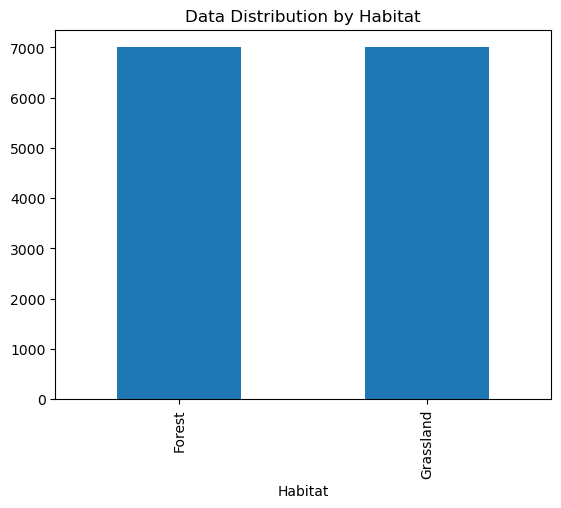

In [68]:
final_data['Habitat'].value_counts().plot(kind='bar', title='Data Distribution by Habitat')

<Axes: title={'center': 'Bird Activity per Habitat'}, xlabel='Habitat'>

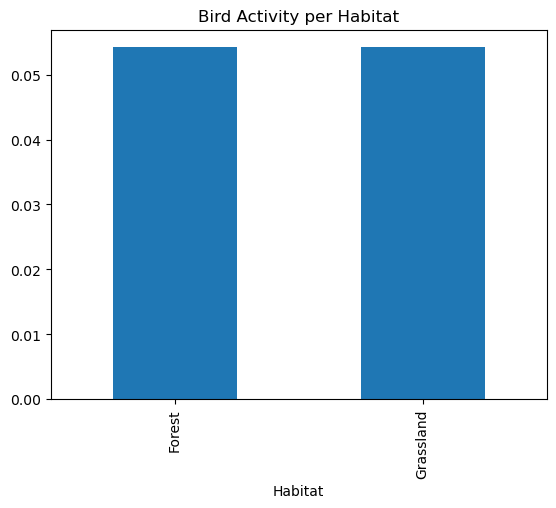

In [69]:
final_data.groupby('Habitat')['Count_per_Min'].mean().plot(kind='bar', title='Bird Activity per Habitat')

<Axes: title={'center': 'Seasonal Bird Activity'}, xlabel='Season'>

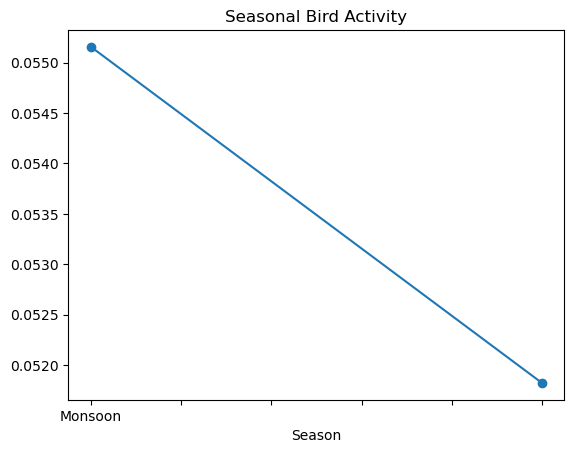

In [70]:
# Seasonal Trends
final_data.groupby('Season')['Count_per_Min'].mean().plot(kind='line', marker='o', title='Seasonal Bird Activity')

<Axes: title={'center': 'Bird Activity by Time of Day'}, xlabel='Time_of_Day'>

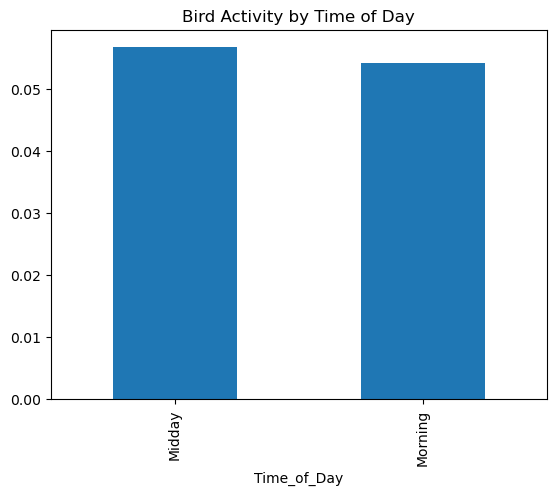

In [71]:
# Time of Day Analysis
final_data.groupby('Time_of_Day')['Count_per_Min'].mean().plot(kind='bar', title='Bird Activity by Time of Day')

<Axes: xlabel='Temp_Category', ylabel='Count_per_Min'>

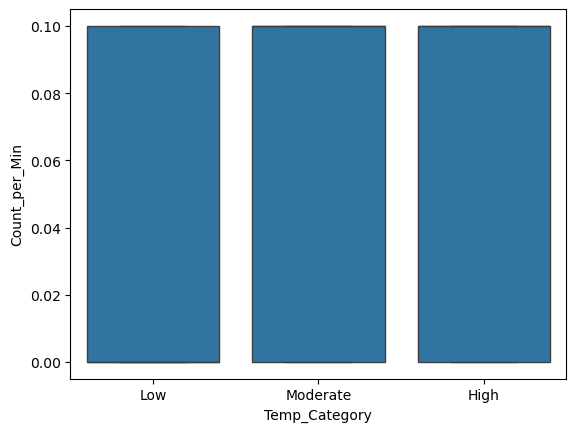

In [72]:
import seaborn as sns
sns.boxplot(x='Temp_Category', y='Count_per_Min', data=final_data)

<Axes: xlabel='Humidity_Level', ylabel='Count_per_Min'>

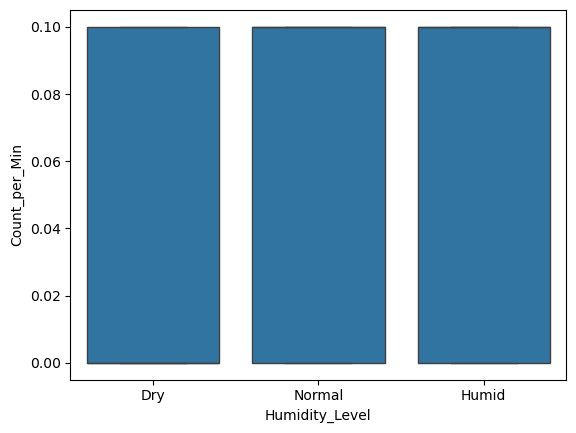

In [73]:
sns.boxplot(x='Humidity_Level', y='Count_per_Min', data=final_data)

<Axes: title={'center': 'Top 10 Bird Species'}, ylabel='Common_Name'>

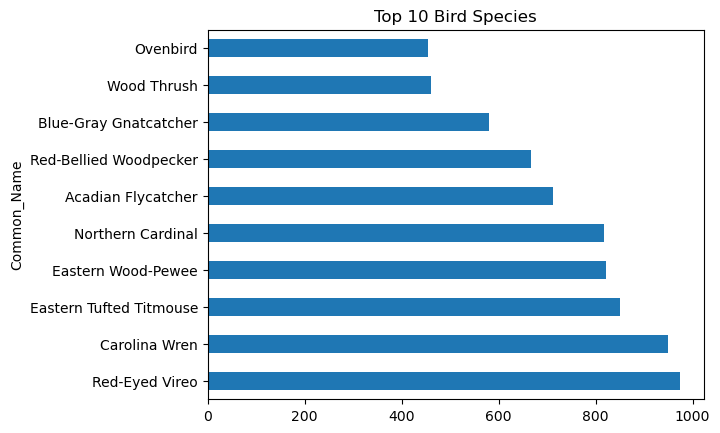

In [74]:
final_data['Common_Name'].value_counts().head(10).plot(kind='barh', title='Top 10 Bird Species')

<Axes: xlabel='Common_Name'>

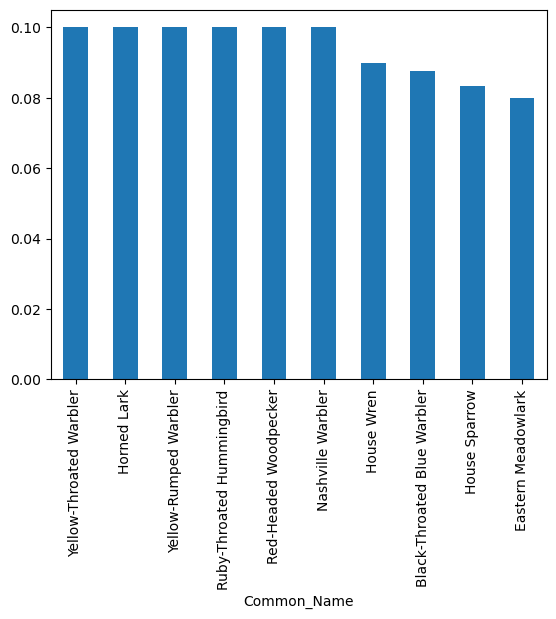

In [75]:
final_data.groupby('Common_Name')['Count_per_Min'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


<Axes: xlabel='Temperature', ylabel='Count_per_Min'>

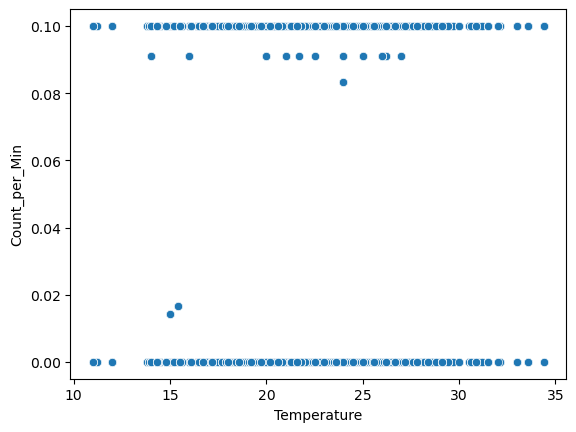

In [76]:
import seaborn as sns

sns.scatterplot(x='Temperature', y='Count_per_Min', data=final_data)

<Axes: xlabel='Season', ylabel='Count_per_Min'>

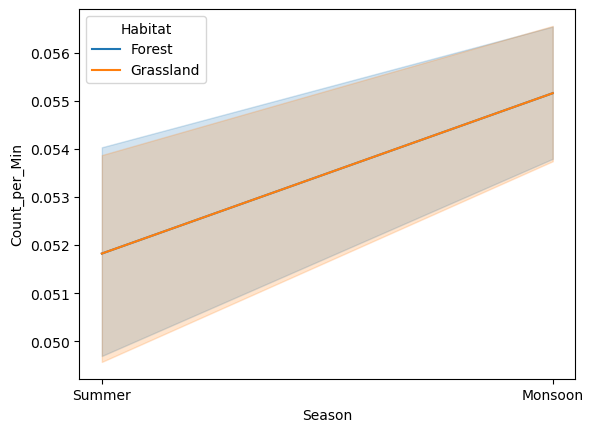

In [77]:
sns.lineplot(x='Season', y='Count_per_Min', hue='Habitat', data=final_data)

<Axes: xlabel='Temperature', ylabel='Count_per_Min'>

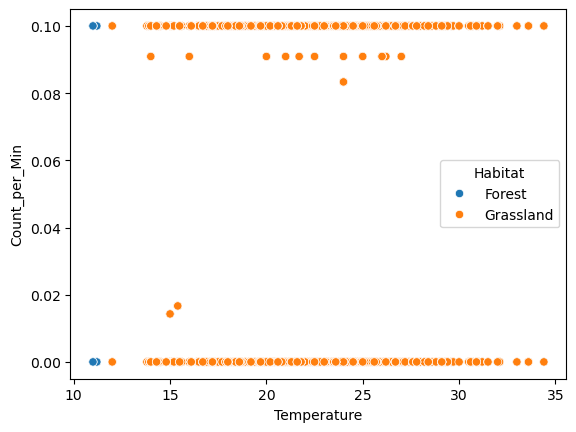

In [78]:
sns.scatterplot(x='Temperature', y='Count_per_Min', hue='Habitat', data=final_data)

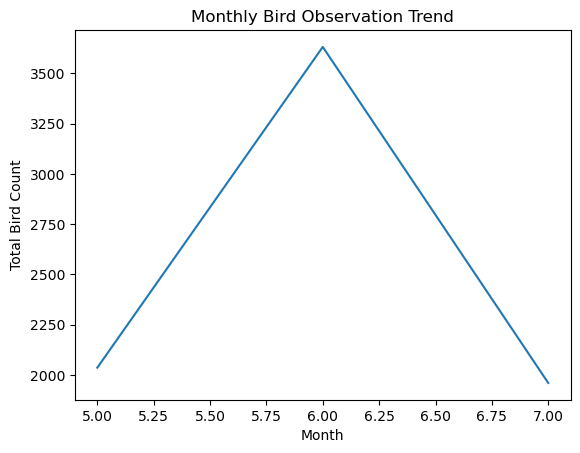

In [79]:

#  Monthly Trend
monthly_counts = final_data.groupby('Month')['Initial_Three_Min_Cnt'].sum()

plt.figure()
monthly_counts.plot(kind='line')
plt.title('Monthly Bird Observation Trend')
plt.xlabel('Month')
plt.ylabel('Total Bird Count')
plt.show()

Text(0.5, 1.0, 'Correlation Analysis')

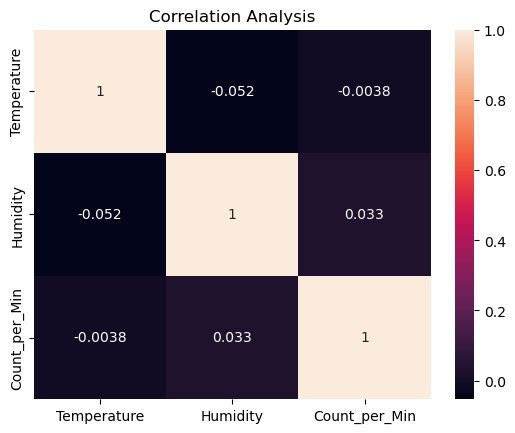

In [80]:
import matplotlib.pyplot as plt

corr = final_data[['Temperature','Humidity','Count_per_Min']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Analysis')

In [81]:
final_data.to_csv("final_bird_dataset.csv",index=False)

In [82]:
import os
print(os.getcwd())

c:\Users\hp\OneDrive\Music\Documents\strava_project


In [83]:
final_data.columns

Index(['Admin_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Year',
       'Date', 'Start_Time', 'End_Time', 'Observer', 'Visit', 'Distance',
       'Flyover_Observed', 'Sex', 'Common_Name', 'Scientific_Name',
       'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Temperature',
       'Humidity', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt',
       'Log_Count', 'Habitat', 'Hour', 'Count_per_Min', 'Month', 'Season',
       'Time_of_Day', 'Temp_Category', 'Humidity_Level', 'Duration_Min',
       'Detected', 'Species_Avg_Count'],
      dtype='object')

In [84]:
final_data.shape

(14010, 35)

In [89]:
df_grouped.columns

Index(['Habitat', 'Plot_Name', 'Date', 'Scientific_Name',
       'Initial_Three_Min_Cnt', 'Temperature', 'Humidity'],
      dtype='object')